## Custom Middleware

In [1]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [2]:
model_free = init_chat_model("llama-3.3-70b-versatile",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [3]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

`HumanInTheLoopMiddleware` handles approval for any tool. PIIMiddleware handles any of five PII types. CineBot's actual business, though, has rules nothing built-in could know in advance: "no customer books more than 2 movies in one session," "flag it if the bot ever mentions a rival cinema chain by name," "log every cancellation in our own specific audit format." Nothing generic can anticipate rules that are yours alone.

In [20]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dunes part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

cinebot_tools = [check_showtimes, book_seats, cancel_booking, get_refund_policy]

# Callbaks, Hooks, Middleware

Hooks are extension points in custom middleware that let you intercept, inspect, or modify agent execution at specific stages of the lifecycle.

In [5]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
    return None  # None means "observed, nothing to change"


In [6]:
@before_agent
def connecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have connected to DB")
    return None  # None means "observed, nothing to change"

In [7]:
@after_agent
def disconnecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have disconnected to DB")
    return None  # None means "observed, nothing to change"

In [8]:
logged_agent = create_agent(model=model_free, tools=[], middleware=[log_before_model,connecting_to_DB,disconnecting_to_DB])


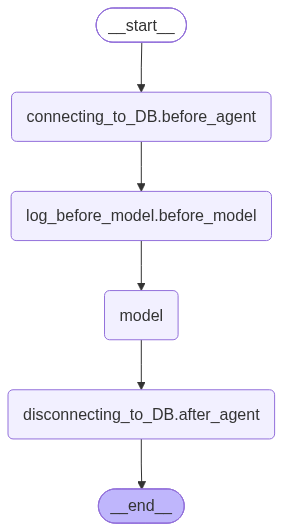

In [9]:
logged_agent

In [10]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]})

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [11]:
result

{'messages': [HumanMessage(content='Hi, How are you?', additional_kwargs={}, response_metadata={}, id='2bbd357d-0a18-44f1-8387-8a483caad1a4'),
  AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 41, 'total_tokens': 91, 'completion_time': 0.100586774, 'completion_tokens_details': None, 'prompt_time': 0.001974305, 'prompt_tokens_details': None, 'queue_time': 0.051193129, 'total_time': 0.102561079}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0098e-7278-7e12-b39f-c6b7a2cbc805-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tok

In [12]:
from rich import print as rprint

In [13]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content='Hi, How are you?',
            additional_kwargs={},
            response_metadata={},
            id='2bbd357d-0a18-44f1-8387-8a483caad1a4'
        ),
        AIMessage(
            content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm 
functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day 
going so far?",
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 50,
                    'prompt_tokens': 41,
                    'total_tokens': 91,
                    'completion_time': 0.100586774,
                    'completion_tokens_details': None,
                    'prompt_time': 0.001974305,
                    'prompt_tokens_details': None,
                    'queue_time': 0.051193129,
                    'total_time': 0.102561079
                },
                'model_name': 'llama-3.3-70b-versatile',
                'system_fingerprint': 'fp_dae98b5ecb',
                'service_tier': 'on_demand',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--01a0098e-7278-7e12-b39f-c6b7a2cbc805-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 41, 'output_tokens': 50, 'total_tokens': 91}
        )
    ]
}

In [14]:
result = logged_agent.invoke({"messages": [("user", "Great")]})

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [15]:
logged_agent = create_agent(model=model_free, tools=[book_seats,cancel_booking], middleware=[log_before_model])

In [16]:
@tool
def book_vip_lounge(movie_title: str) -> str:
    """Book a VIP lounge seat with premium service. VIP members only."""
    return f"VIP lounge seat booked for {movie_title}."

In [17]:
@wrap_model_call
def gate_vip_tools(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Only expose book_vip_lounge to VIP members."""
    is_vip = request.state.get("is_vip_member", False)
    if not is_vip:
        allowed = [t for t in request.tools if t.name != "book_vip_lounge"]
        request = request.override(tools=allowed)
    return handler(request)

In [21]:
gated_agent = create_agent(model=model_advanced, tools=[*cinebot_tools, book_vip_lounge], middleware=[gate_vip_tools])
result = gated_agent.invoke({"messages": [("user", "Book me a VIP lounge seat for Dunes")]})
print(result["messages"][-1].content)

Could you clarify which movie you mean by “Dunes” and how many seats you need? The booking system also doesn’t specify VIP lounge seating, so I’ll need to confirm whether a standard seat is acceptable.


In [24]:
result_vip = gated_agent.invoke({
    "messages": [("user", "Book me one VIP lounge seat for Dunes")],
    "is_vip_member": True,
})
print(result_vip["messages"][-1].content)


I can book one seat for **“Dunes,”** but the booking system doesn’t let me specify **VIP lounge** seating. Would you like me to proceed with one standard seat, or should I leave it unbooked?


In [25]:
rprint(result_vip)

{
    'messages': [
        HumanMessage(
            content='Book me one VIP lounge seat for Dunes',
            additional_kwargs={},
            response_metadata={},
            id='cd6d1331-a8da-4423-80fe-7a7e4c8880d2'
        ),
        AIMessage(
            content='I can book one seat for **“Dunes,”** but the booking system doesn’t let me specify **VIP 
lounge** seating. Would you like me to proceed with one standard seat, or should I leave it unbooked?',
            additional_kwargs={
                'reasoning_content': '**Clarifying booking details**\n\nI need to clarify if the movie title is 
"Dune." The booking tool only allows a count of seats and doesn\'t let me select a VIP lounge seat, which isn\'t 
ideal. I\'ll have to explain this limitation to the user. I could check the showtimes for "Dune" to provide 
accurate information. It\'s essential I don\'t make a mistake with the booking, so I\'ll ask for clarification on 
the title and mention the tool\'s limitations.',
                'reasoning_details': [
                    {
                        'summary': '**Clarifying booking details**\n\nI need to clarify if the movie title is 
"Dune." The booking tool only allows a count of seats and doesn\'t let me select a VIP lounge seat, which isn\'t 
ideal. I\'ll have to explain this limitation to the user. I could check the showtimes for "Dune" to provide 
accurate information. It\'s essential I don\'t make a mistake with the booking, so I\'ll ask for clarification on 
the title and mention the tool\'s limitations.',
                        'type': 'reasoning.summary',
                        'format': 'azure-openai-responses-v1',
                        'index': 0
                    },
                    {
                        'data': 
'gAAAAABqgW8cFPH9DyyWu_62jNuyQHxo3w1M03VMKofl35x6ZlnsZBg90fwIkDfbrLQ_0LQm8BXnHlxPn0m6JAXusAEHPTAm7JpDUcF5tAT6GMaPam
f5KCiH2zsTmGtGBtqWWQryD86PXaXrT53aN6lcxmb060czfe_uvOtUcqxZOjRNqKzDqDSCzowXTKRPirOTh3tOYcmfP94w4feTUxnUbQgHBqY4IQDud
PQtLviKCErFPndRZq9158R5a38FslKLuSm6RZzZYk6LOWV1pImvO7BbRj3th3OxmXfIy7FneK-CHiSfFQlLROKSsUwKZU_1dctr9d8heZ9PowJlSPpD
gAJWnA-pKNuBxOSGYR2MoXFSxqS3zIZPsl_D7tRwEtqrsN2xAxjw9g5p4cLrXzREMUp0us9YEgN-3TeQuQa6nP5khbU-ex3TVcn_YIkuUbJi4ichQWT
ZQyRWI666oxU1WLkdHJrMG5-SZDr8TjJOC_qlQcZBBseESgGG4tKA-El0I32BTqz_xJptAfcwt6GJxYj9qk7XLForu3B6sZUaTv2CczZbhGyO64DN1B
8t6DFhQx6tKPvrA3DgmCnYgHUYsrIYoYQ4Qc39-c4Cr4QQBWONu1KDm1mW--M7mOSLw_zZwiAWxtq1c25RHqS2A9KhlNQLs2rLCzF1yqbrThHGs3wbv
b04PI_LWBW7FKnlh1o4k3gUBAtH0bLqcQ9kdmlpgqj907EATGRuJIDBRmbwP5WnzOltkMOXrOGFQe3afDJwvmHMYgbh3VSbU7SAG0OtrkqAuDcrHt4o
KokFg91SaR-XIEHtPhVHGE0rfIqS8OdQfVJzhea6chTabc7RtMlirnPj3jBAK4P3qWpdcYvoMdTghOorO5lBblwVnUcknF1YMF_FXhLpWz2PXDH3sgc
IYsp3li60YpmgDhB5GTo_XRW0aEcK6bNPtjSFE0v5rumIHo8_uPXQhYSZGufo61t_AHy--ASobGxOnEiv0FqW297eNe5QFVSQKM173HAOZC_3rhIUW1
VHSWYV5RJP2i6oYSKG3wP60uTulAHA6WFEf7s2A6bpiKg_jUSFFwuJw9UZ1fute1SYH5BP87jPUO_JTr30WuAldb8cueTfdBML6gvnBYKVkfFZNq-kr
xv1_kbNpaH1XoSAZ3O3a5K-33tHJObFWC93DBw2BTaQ2cpxs5DtpKGlz0DVQxt3MMoT5eaTV7VReuimUdy66_chp_MFc_C2Ml-FheGLH0YjjfImzvcN
4DAO-ALdkRdn3gKrskvuYfUt7dhb2-AkV3H18rnvL_u_qzYlODIfxfwfNbiojJKcycF3yFe7vVsvoT6GN0aaisNzQ9-KTJQcQuY5nkNYQZkaC3igDzL
IDE8ISzIroU4aFM14U5MiLSoKbVYx96rUMlJuZVptjhpit2URXtLx4uFmZJ33RQ==.eyJlbmRwb2ludF9zbHVnIjoib3BlbmFpL2dwdC01LjYtbHVuY
S1wcm8tMjAyNjA3MDl8YXp1cmUifQ',
                        'type': 'reasoning.encrypted',
                        'format': 'azure-openai-responses-v1',
                        'id': 'rs_0d08b0186a4e9db2016a816f1b7e1c8196b247324d6253dcbe',
                        'index': 1
                    }
                ]
            },
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna-pro',
                'id': 'gen-1786867471-CUg0HSmIoqOEQfRNxwB5',
                'created': 1786867471,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter',
                'c